# End-to-End ML Pipeline for Weather Delay Prediction
This notebook handles flight data preprocessing, bulk weather data fetching, 4-way time merging, and predictive modeling.


In [2]:
import pandas as pd
import numpy as np
import os
import glob
import requests
import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pytz
from timezonefinder import TimezoneFinder
import math

pd.set_option('display.max_columns', None)


## Phase 1: Flight Data Preprocessing
Here we load all the CSV files, handle missing dates, drop cancellations and duplicates, and address class imbalance. If you've already run this, it will load the cached output directly.


In [ ]:
# Phase 1: Initialize or Load Cache
if os.path.exists("02_flights_balanced.csv"):
    print("Found 02_flights_balanced.csv! Loading cached data...")
    flights_balanced = pd.read_csv("02_flights_balanced.csv", low_memory=False)
    
    # Check if this is an old cache without dt_local columns
    if 'crs_dep_dt_local' not in flights_balanced.columns:
        print("Old cache format detected. Generating local datetime columns...")
        def clean_time(time_val):
            if pd.isna(time_val): return '0000'
            t = int(float(time_val))
            if t >= 2400: t = 0
            return f"{t:04d}"
        
        flights_balanced['FL_DATE'] = pd.to_datetime(flights_balanced['FL_DATE'])
        flights_balanced['crs_dep_str'] = flights_balanced['CRS_DEP_TIME'].apply(clean_time)
        flights_balanced['dep_str'] = flights_balanced['DEP_TIME'].apply(clean_time)
        flights_balanced['crs_arr_str'] = flights_balanced['CRS_ARR_TIME'].apply(clean_time)
        flights_balanced['arr_str'] = flights_balanced['ARR_TIME'].apply(clean_time)
        
        flights_balanced['crs_dep_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['crs_dep_str'], format='%Y-%m-%d %H%M', errors='coerce')
        flights_balanced['dep_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['dep_str'], format='%Y-%m-%d %H%M', errors='coerce')
        flights_balanced['crs_arr_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['crs_arr_str'], format='%Y-%m-%d %H%M', errors='coerce')
        flights_balanced['arr_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['arr_str'], format='%Y-%m-%d %H%M', errors='coerce')
        flights_balanced = flights_balanced.dropna(subset=['crs_dep_dt_local', 'dep_dt_local', 'crs_arr_dt_local', 'arr_dt_local'])
        
        # Resave it in the new format
        flights_balanced.to_csv("02_flights_balanced.csv", index=False)
        print("Upgraded and re-saved 02_flights_balanced.csv.")

    # Convert string dates back to datetime objects
    date_cols = ['FL_DATE', 'crs_dep_dt_local', 'dep_dt_local', 'crs_arr_dt_local', 'arr_dt_local']
    for col in date_cols:
        if col in flights_balanced.columns:
            flights_balanced[col] = pd.to_datetime(flights_balanced[col], errors='coerce')
            
    skip_raw = True
    print(f"Loaded {len(flights_balanced):,} flights. Skipping to Phase 2.")
else:
    skip_raw = False
    print("No cached dataset found. Proceeding with raw data processing in following cells.")



In [ ]:
# 1. Load Data
if not skip_raw:
    flight_data_dir = r"raw-data-reduced-min-2024"
    all_files = glob.glob(os.path.join(flight_data_dir, "T_ONTIME_REPORTING_*", "T_ONTIME_REPORTING.csv"))
    
    print(f"Found {len(all_files)} files. Loading data...")
    dfs = []
    for file in all_files:
        df = pd.read_csv(file, low_memory=False)
        dfs.append(df)
    
    flights = pd.concat(dfs, ignore_index=True)
    print(f"Total flights loaded: {len(flights):,}")


In [ ]:
# 2. Date Reconstruction and Cleaning
if not skip_raw:
    flights = flights.loc[:, ~flights.columns.str.contains('^Unnamed')]
    flights = flights[flights['CANCELLED'] != 1].copy()
    print(f"Flights after removing cancellations: {len(flights):,}")
    
    delay_cols = ['WEATHER_DELAY', 'NAS_DELAY', 'LATE_AIRCRAFT_DELAY']
    for col in delay_cols:
        if col in flights.columns:
            flights[col] = flights[col].fillna(0)
            
    flights['FL_DATE'] = pd.to_datetime(flights[['YEAR', 'MONTH', 'DAY_OF_MONTH']].rename(columns={'YEAR':'year', 'MONTH':'month', 'DAY_OF_MONTH':'day'}))


In [ ]:
# 3. Deduplication
if not skip_raw:
    dedup_cols = ['FL_DATE', 'OP_UNIQUE_CARRIER', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'DEST']
    flights = flights.drop_duplicates(subset=dedup_cols, keep='first')
    print(f"Flights after removing duplicates: {len(flights):,}")
    flights.to_csv("01_flights_deduplicated.csv", index=False)
    print("Saved 01_flights_deduplicated.csv")


In [ ]:
# 4. Balancing (Undersampling Non-Delayed Flights)
if not skip_raw:
    delayed = flights[flights['WEATHER_DELAY'] > 0]
    not_delayed = flights[flights['WEATHER_DELAY'] == 0]
    
    print(f"Delayed flights: {len(delayed):,}")
    print(f"Non-delayed flights: {len(not_delayed):,}")
    
    if len(delayed) > 0:
        not_delayed_sampled = not_delayed.sample(n=len(delayed), random_state=42)
        flights_balanced = pd.concat([delayed, not_delayed_sampled])
        flights_balanced = flights_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
    else:
        print("Warning: No delayed flights found!")
        flights_balanced = flights.copy()
        
    print(f"Total flights after balancing: {len(flights_balanced):,}")


In [ ]:
# 5. Time Formatting and UTC Conversion
if not skip_raw:
    def clean_time(time_val):
        if pd.isna(time_val): return '0000'
        t = int(float(time_val))
        if t >= 2400: t = 0
        return f"{t:04d}"
    
    flights_balanced['crs_dep_str'] = flights_balanced['CRS_DEP_TIME'].apply(clean_time)
    flights_balanced['dep_str'] = flights_balanced['DEP_TIME'].apply(clean_time)
    flights_balanced['crs_arr_str'] = flights_balanced['CRS_ARR_TIME'].apply(clean_time)
    flights_balanced['arr_str'] = flights_balanced['ARR_TIME'].apply(clean_time)
    
    flights_balanced['crs_dep_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['crs_dep_str'], format='%Y-%m-%d %H%M', errors='coerce')
    flights_balanced['dep_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['dep_str'], format='%Y-%m-%d %H%M', errors='coerce')
    flights_balanced['crs_arr_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['crs_arr_str'], format='%Y-%m-%d %H%M', errors='coerce')
    flights_balanced['arr_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['arr_str'], format='%Y-%m-%d %H%M', errors='coerce')
    
    flights_balanced = flights_balanced.dropna(subset=['crs_dep_dt_local', 'dep_dt_local', 'crs_arr_dt_local', 'arr_dt_local'])
    
    # Save AFTER time formatting
    flights_balanced.to_csv("02_flights_balanced.csv", index=False)
    print(f"Saved 02_flights_balanced.csv with {len(flights_balanced):,} records")


## Phase 2: Bulk Weather Data Fetching
Fetch weather data for unique airports over the required date range. We no longer rely on prefix guessing, but instead map IATA to exact ICAO codes.


In [ ]:
# Get unique origin and dest airports
all_required_airports = set(flights_balanced['ORIGIN'].unique()).union(set(flights_balanced['DEST'].unique()))
print(f"Total unique airports to fetch weather for: {len(all_required_airports)}")

WEATHER_DIR = "weather_data"
if not os.path.exists(WEATHER_DIR):
    os.makedirs(WEATHER_DIR)

import io

print("Downloading IATA to ICAO mapping from OurAirports...")
url = "https://davidmegginson.github.io/ourairports-data/airports.csv"
try:
    response = requests.get(url, timeout=30)
    airports_df = pd.read_csv(io.StringIO(response.text))
    us_airports = airports_df[(airports_df['iso_country'] == 'US') & (airports_df['iata_code'].notna())]
    iata_to_icao = dict(zip(us_airports['iata_code'], us_airports['ident']))
    print(f"Successfully loaded mapping for {len(iata_to_icao)} airports.")
except Exception as e:
    print(f"Warning: Could not download mapping ({e}).")
    iata_to_icao = {}

# Uncomment the following to execute the fetch. (Skipped by default to prevent accidental massive API usage)

def fetch_weather_bulk(airports, year):
    # This function fetches entire year data per airport
    for apt in airports:
        # Look up the exact ICAO code from our dictionary
        icao = iata_to_icao.get(apt)
        
        if not icao:
            print(f"Skipping {apt}: No valid ICAO code found in OurAirports dataset.")
            continue
            
        out_path = os.path.join(WEATHER_DIR, f"{icao}_{year}.csv")
        
        # Skip if already downloaded and valid
        if os.path.exists(out_path) and os.path.getsize(out_path) > 300: 
            continue
        
        print(f"Fetching {icao} for {year}...")
        url = (
            f"https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?"
            f"station={icao}&data=all&"
            f"year1={year}&month1=1&day1=1&"
            f"year2={year}&month2=12&day2=31&"
            f"tz=UTC&format=onlycomma&latlon=yes&missing=empty&trace=T&direct=yes&report_type=1&report_type=2"
        )
        try:
            r = requests.get(url, timeout=60)
            if r.status_code == 200:
                if len(r.text) > 300:
                    with open(out_path, 'w') as f:
                        f.write(r.text)
                else:
                    print(f"  {icao} returned empty data.")
        except Exception as e:
            print(f"Error fetching {icao}: {e}")

print("Starting bulk weather download for 2024. This will download CSV files to your weather_data folder.")
print("This may take 5-10 minutes. Please be patient...")
fetch_weather_bulk(list(all_required_airports), 2024)


## Phase 3: Data Merging (4-Way Merge)
Merge the cached weather data into the flight rows for the 4 distinct times.


In [ ]:
# Build ICAO to IATA map so we can convert downloaded weather files back to standard IATA codes for the merge
icao_to_iata = {v: k for k, v in iata_to_icao.items()} if 'iata_to_icao' in locals() else {}

# 1. Quick Pass: Extract valid airports and their coordinates
weather_files = glob.glob(os.path.join(WEATHER_DIR, "*.csv"))
valid_airports = set()
airport_coords_list = []

print("Scanning weather files to extract available airports and coordinates...")
for f in weather_files:
    filename = os.path.basename(f)
    icao_code = filename.split('_')[0]
    iata_code = icao_to_iata.get(icao_code)
    
    if not iata_code:
        iata_code = icao_code[1:] if len(icao_code) == 4 and icao_code[0] in ['K', 'P', 'T'] else icao_code
    
    try:
        # Read just the first few rows to get lat/lon quickly
        head = pd.read_csv(f, nrows=1, on_bad_lines='skip')
        if 'lat' in head.columns and 'lon' in head.columns:
            airport_coords_list.append({'AIRPORT': iata_code, 'lat': head['lat'].iloc[0], 'lon': head['lon'].iloc[0]})
            valid_airports.add(iata_code)
    except:
        continue

if not weather_files:
    print("No weather data found to merge. Please run the fetch function.")
else:
    # 2. Filter flights and apply timezones
    original_len = len(flights_balanced)
    flights_balanced = flights_balanced[
        flights_balanced['ORIGIN'].isin(valid_airports) & 
        flights_balanced['DEST'].isin(valid_airports)
    ].copy()
    print(f"Dropped {original_len - len(flights_balanced):,} flights due to missing weather data.")

    airport_coords = pd.DataFrame(airport_coords_list).drop_duplicates(subset=['AIRPORT'])

    # Map lat/lon to Timezones
    from timezonefinder import TimezoneFinder
    tf = TimezoneFinder()
    tz_dict = {}
    for _, row in airport_coords.iterrows():
        try:
            tz = tf.timezone_at(lng=row['lon'], lat=row['lat'])
            if tz: tz_dict[row['AIRPORT']] = tz
        except:
            continue

    # Apply timezones to flight dataset
    flights_balanced['ORIGIN_TZ'] = flights_balanced['ORIGIN'].map(tz_dict)
    flights_balanced['DEST_TZ'] = flights_balanced['DEST'].map(tz_dict)
    flights_balanced = flights_balanced.dropna(subset=['ORIGIN_TZ', 'DEST_TZ'])

    def convert_to_utc(dt_series, tz_series):
        utc_series = pd.Series(index=dt_series.index, dtype='datetime64[ns, UTC]')
        for tz, group in dt_series.groupby(tz_series):
            local_time = group.dt.tz_localize(tz, ambiguous='NaT', nonexistent='NaT')
            utc_series.loc[group.index] = local_time.dt.tz_convert('UTC')
        return utc_series

    print("Converting naive flight times to UTC using exact airport coordinates...")
    flights_balanced['ORIGIN_CRS_DEP_UTC'] = convert_to_utc(flights_balanced['crs_dep_dt_local'], flights_balanced['ORIGIN_TZ']).dt.tz_localize(None)
    flights_balanced['ORIGIN_DEP_UTC'] = convert_to_utc(flights_balanced['dep_dt_local'], flights_balanced['ORIGIN_TZ']).dt.tz_localize(None)
    flights_balanced['DEST_CRS_ARR_UTC'] = convert_to_utc(flights_balanced['crs_arr_dt_local'], flights_balanced['DEST_TZ']).dt.tz_localize(None)
    flights_balanced['DEST_ARR_UTC'] = convert_to_utc(flights_balanced['arr_dt_local'], flights_balanced['DEST_TZ']).dt.tz_localize(None)

    flights_balanced = flights_balanced.dropna(subset=['ORIGIN_CRS_DEP_UTC', 'ORIGIN_DEP_UTC', 'DEST_CRS_ARR_UTC', 'DEST_ARR_UTC'])

    # We MUST preserve the original index to stitch the chunks back together
    flights_balanced = flights_balanced.reset_index(drop=True)
    flights_balanced.to_csv("03_flights_time_formatted.csv", index=False)
    print("Saved 03_flights_time_formatted.csv")


## Phase 3.5: Memory-Efficient Airport-by-Airport Merge
Here we iterate through each weather file, matching its readings to the flights associated with that airport to prevent Out of Memory errors.


In [ ]:
if not weather_files:
    print("Skipping merge because no weather files exist.")
else:
    # Get columns from a sample weather file
    sample_wdf = pd.read_csv(weather_files[0], nrows=1, on_bad_lines='skip', low_memory=False)
    non_feat = ['station', 'valid', 'lon', 'lat', 'AIRPORT', 'WEATHER_UTC']
    feat_cols = [c for c in sample_wdf.columns if c not in non_feat]

    rename_o_crs = {c: f'O_CRS_{c}' for c in feat_cols}
    rename_o_act = {c: f'O_ACT_{c}' for c in feat_cols}
    rename_d_crs = {c: f'D_CRS_{c}' for c in feat_cols}
    rename_d_act = {c: f'D_ACT_{c}' for c in feat_cols}

    origin_chunks = []
    dest_chunks = []

    print(f"Starting chunked merge across {len(weather_files)} airports...")

    for f in weather_files:
        filename = os.path.basename(f)
        icao_code = filename.split('_')[0]
        iata_code = icao_to_iata.get(icao_code)
        if not iata_code:
            iata_code = icao_code[1:] if len(icao_code) == 4 and icao_code[0] in ['K', 'P', 'T'] else icao_code
        
        # Check if this airport actually has flights associated with it
        has_origin = (flights_balanced['ORIGIN'] == iata_code).any()
        has_dest = (flights_balanced['DEST'] == iata_code).any()
        
        if not (has_origin or has_dest):
            continue # Skip loading weather if no flights use it
            
        # Load this airport's weather
        wdf = pd.read_csv(f, on_bad_lines='skip', low_memory=False)
        wdf['WEATHER_UTC'] = pd.to_datetime(wdf['valid']).dt.tz_localize(None)
        wdf = wdf.sort_values('WEATHER_UTC')
        wdf = wdf.replace({'M': pd.NA, 'T': 0.001})
        for col in feat_cols:
            if col in wdf.columns:
                wdf[col] = pd.to_numeric(wdf[col], errors='coerce')
                
        # Forward fill up to 12 rows (approx 1 hour of 5-min intervals) to handle fragmented sensor reports
        wdf[feat_cols] = wdf[feat_cols].ffill(limit=12)
                
        # --- Origin Merge ---
        if has_origin:
            origin_flights = flights_balanced[flights_balanced['ORIGIN'] == iata_code][['ORIGIN_CRS_DEP_UTC', 'ORIGIN_DEP_UTC']].copy()
            origin_flights['original_index'] = origin_flights.index
            
            m1 = pd.merge_asof(
                origin_flights.sort_values('ORIGIN_CRS_DEP_UTC'), 
                wdf[['WEATHER_UTC'] + feat_cols].rename(columns=rename_o_crs),
                left_on='ORIGIN_CRS_DEP_UTC', right_on='WEATHER_UTC', direction='backward'
            ).drop(columns=['WEATHER_UTC'])
            
            m2 = pd.merge_asof(
                m1.sort_values('ORIGIN_DEP_UTC'), 
                wdf[['WEATHER_UTC'] + feat_cols].rename(columns=rename_o_act),
                left_on='ORIGIN_DEP_UTC', right_on='WEATHER_UTC', direction='backward'
            ).drop(columns=['WEATHER_UTC'])
            
            m2 = m2.set_index('original_index')
            feat_cols_o = [c for c in m2.columns if c.startswith('O_')]
            origin_chunks.append(m2[feat_cols_o])

        # --- Dest Merge ---
        if has_dest:
            dest_flights = flights_balanced[flights_balanced['DEST'] == iata_code][['DEST_CRS_ARR_UTC', 'DEST_ARR_UTC']].copy()
            dest_flights['original_index'] = dest_flights.index
            
            m3 = pd.merge_asof(
                dest_flights.sort_values('DEST_CRS_ARR_UTC'), 
                wdf[['WEATHER_UTC'] + feat_cols].rename(columns=rename_d_crs),
                left_on='DEST_CRS_ARR_UTC', right_on='WEATHER_UTC', direction='backward'
            ).drop(columns=['WEATHER_UTC'])
            
            m4 = pd.merge_asof(
                m3.sort_values('DEST_ARR_UTC'), 
                wdf[['WEATHER_UTC'] + feat_cols].rename(columns=rename_d_act),
                left_on='DEST_ARR_UTC', right_on='WEATHER_UTC', direction='backward'
            ).drop(columns=['WEATHER_UTC'])
            
            m4 = m4.set_index('original_index')
            feat_cols_d = [c for c in m4.columns if c.startswith('D_')]
            dest_chunks.append(m4[feat_cols_d])

    print("Stitching all matched weather features back to the flights dataset...")
    all_origin_features = pd.concat(origin_chunks) if origin_chunks else pd.DataFrame()
    all_dest_features = pd.concat(dest_chunks) if dest_chunks else pd.DataFrame()

    # Join by the original flight index
    final_merged = flights_balanced.join(all_origin_features).join(all_dest_features)

    final_merged.to_csv("04_flights_weather_merged.csv", index=False)
    print("Merged dataset created successfully and saved as 04_flights_weather_merged.csv!")


## Phase 4: EDA & Modeling
Analyze features and train baseline models.


================ ALL COLUMNS IN FINAL DATASET ================
  0: YEAR
  1: MONTH
  2: DAY_OF_MONTH
  3: FL_DATE
  4: OP_UNIQUE_CARRIER
  5: OP_CARRIER_AIRLINE_ID
  6: OP_CARRIER
  7: TAIL_NUM
  8: OP_CARRIER_FL_NUM
  9: ORIGIN
 10: ORIGIN_STATE_ABR
 11: DEST
 12: DEST_STATE_ABR
 13: CRS_DEP_TIME
 14: DEP_TIME
 15: DEP_DELAY
 16: DEP_DELAY_NEW
 17: DEP_DEL15
 18: CRS_ARR_TIME
 19: ARR_TIME
 20: ARR_DELAY
 21: ARR_DELAY_NEW
 22: ARR_DEL15
 23: CANCELLED
 24: CANCELLATION_CODE
 25: DIVERTED
 26: FLIGHTS
 27: WEATHER_DELAY
 28: NAS_DELAY
 29: LATE_AIRCRAFT_DELAY
 30: DIV_AIRPORT_LANDINGS
 31: DIV_REACHED_DEST
 32: DIV_ARR_DELAY
 33: crs_dep_str
 34: dep_str
 35: crs_arr_str
 36: arr_str
 37: crs_dep_dt_local
 38: dep_dt_local
 39: crs_arr_dt_local
 40: arr_dt_local
 41: ORIGIN_TZ
 42: DEST_TZ
 43: ORIGIN_CRS_DEP_UTC
 44: ORIGIN_DEP_UTC
 45: DEST_CRS_ARR_UTC
 46: DEST_ARR_UTC
 47: O_CRS_tmpf
 48: O_CRS_dwpf
 49: O_CRS_relh
 50: O_CRS_drct
 51: O_CRS_sknt
 52: O_CRS_p01i
 53: O_CRS_alti
 

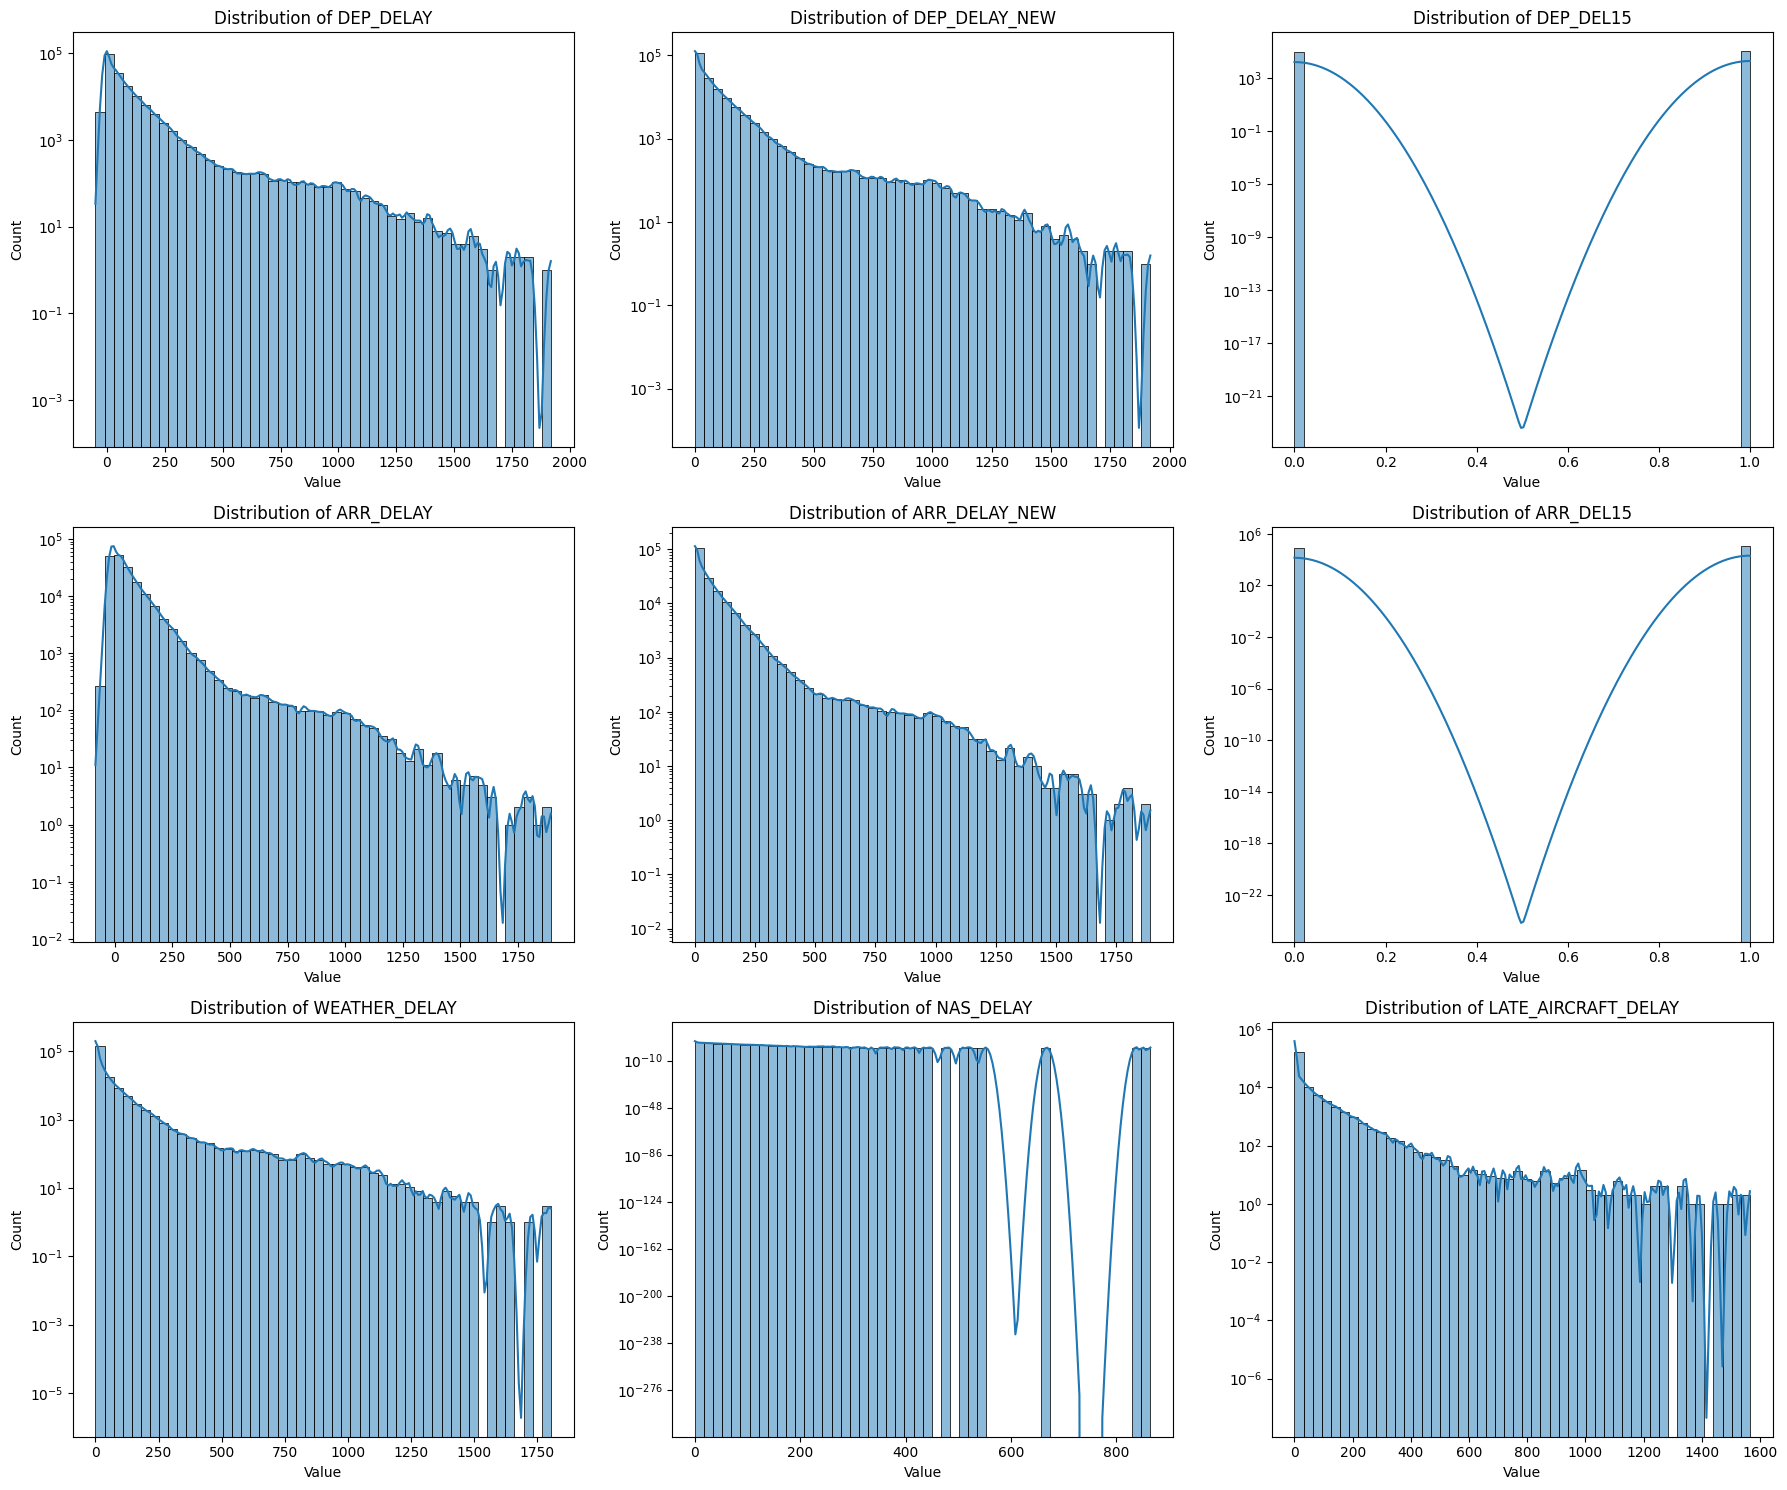

--- Random Forest Results ---
RMSE: 91.24
MAE: 46.06
R2: 0.0553



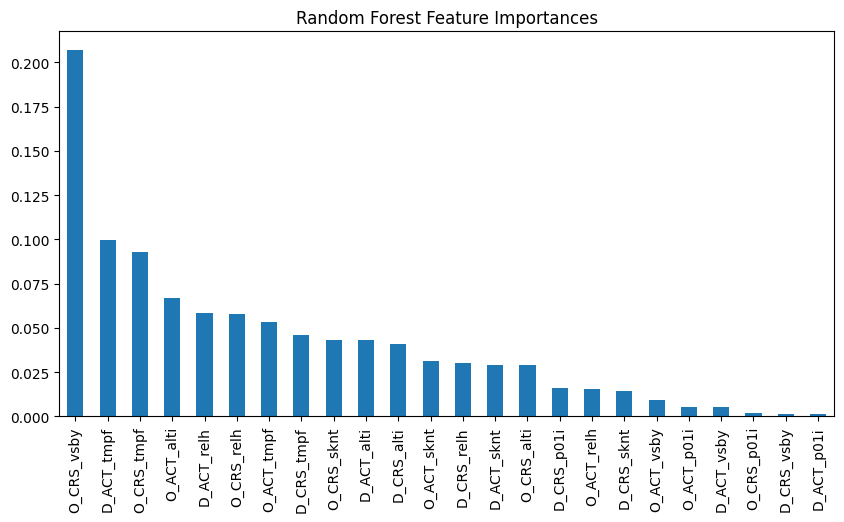

In [3]:
# Load final dataset
if os.path.exists("04_flights_weather_merged.csv"):
    df = pd.read_csv("04_flights_weather_merged.csv")
    
    print("================ ALL COLUMNS IN FINAL DATASET ================")
    for i, col in enumerate(df.columns):
        print(f"{i:3d}: {col}")
    print("==============================================================")
    
    # --- DROP COLUMNS HERE ---
    # Edit the list below to drop any columns you don't want before model training
    columns_to_drop = [
        # Example: 'O_CRS_skyc1', 'D_ACT_vsby', 'CANCELLATION_CODE'
    ]
    if columns_to_drop:
        df = df.drop(columns=columns_to_drop, errors='ignore')
        print(f"\nDropped {len(columns_to_drop)} columns. Remaining columns: {len(df.columns)}")
    # -------------------------
    
    # Basic EDA: Distributions of Delay Columns
    delay_columns_to_plot = [
        'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15',
        'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15',
        'WEATHER_DELAY', 'NAS_DELAY', 'LATE_AIRCRAFT_DELAY'
    ]
    
    print("Generating distribution charts for delay metrics...")
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()
    for i, col in enumerate(delay_columns_to_plot):
        if col in df.columns:
            sns.histplot(df[col].dropna(), bins=50, ax=axes[i], kde=True)
            axes[i].set_title(f"Distribution of {col}")
            axes[i].set_xlabel("Value")
            axes[i].set_ylabel("Count")
            # Set log scale for y-axis to see tails better, given high zero-inflation
            axes[i].set_yscale('log')
    plt.tight_layout()
    plt.show()

    # Basic EDA: Correlation (Currently Disabled)
    '''
    weather_feats = [c for c in df.columns if any(x in c for x in ['_tmpf', '_sknt', '_vsby', '_p01i', '_relh', '_alti'])]
    corr = df[weather_feats + ['WEATHER_DELAY']].corr()
    
    plt.figure(figsize=(12,10))
    sns.heatmap(corr, annot=False, cmap='coolwarm')
    plt.title("Correlation Matrix: Weather Features vs Delay")
    plt.show()
    '''

    # Modeling
    weather_feats = [c for c in df.columns if any(x in c for x in ['_tmpf', '_sknt', '_vsby', '_p01i', '_relh', '_alti'])]
    df_model = df.dropna(subset=weather_feats + ['WEATHER_DELAY'])
    X = df_model[weather_feats]
    y = df_model['WEATHER_DELAY']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # --- Random Forest Regressor (Active) ---
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    print("--- Random Forest Results ---")
    from sklearn.metrics import root_mean_squared_error
    print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"R2: {r2_score(y_test, y_pred):.4f}\n")
    
    # Feature Importance
    feat_imps = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    feat_imps.plot(kind='bar', figsize=(10,5))
    plt.title("Random Forest Feature Importances")
    plt.show()
    
    # --- Alternative Models (Disabled) ---
    '''
    # 1. Simple Linear Regression
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    print("--- Linear Regression Results ---")
    print(f"RMSE: {mean_squared_error(y_test, y_pred_lr, squared=False):.2f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")
    print(f"R2: {r2_score(y_test, y_pred_lr):.4f}\n")
    
    # 2. Support Vector Machine (SVR) 
    # Note: SVR is very slow on large datasets, we strongly recommend scaling X first!
    from sklearn.svm import SVR
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Using a subset for SVM to save time (uncomment [:] to run on full dataset)
    svr = SVR(kernel='rbf', C=1.0)
    svr.fit(X_train_scaled[:10000], y_train[:10000]) # Train on 10k samples
    y_pred_svr = svr.predict(X_test_scaled)
    print("--- SVM Results ---")
    print(f"RMSE: {mean_squared_error(y_test, y_pred_svr, squared=False):.2f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred_svr):.2f}")
    print(f"R2: {r2_score(y_test, y_pred_svr):.4f}\n")
    
    # 3. Simple Neural Network (MLPRegressor)
    from sklearn.neural_network import MLPRegressor
    mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    mlp.fit(X_train_scaled, y_train)
    y_pred_mlp = mlp.predict(X_test_scaled)
    print("--- Neural Network Results ---")
    print(f"RMSE: {mean_squared_error(y_test, y_pred_mlp, squared=False):.2f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred_mlp):.2f}")
    print(f"R2: {r2_score(y_test, y_pred_mlp):.4f}\n")
    '''
